# Распознавание рукописных цифр нейронной сетью с плотными слоями

Практическое занятие №3

Здесь создается и обучается нейронная сеть для распознавания цифр, изображенных на картинках. То есть на вход нейросети будет приходить картинка с числом, а на выходе вы получите само число.

In [30]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

In [31]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


###Загружаем набор данных с рукописными цифрами

In [32]:
# В Keras встроены средства работы с популярными наборами данных
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

###Вывод размерностей данных базы Mnist

In [33]:
print(x_train_org.shape)
print(x_test_org.shape)

(60000, 28, 28)
(10000, 28, 28)


In [34]:
print(y_train_org.shape)
print(y_test_org.shape)

(60000,)
(10000,)


###Вывод примера числа

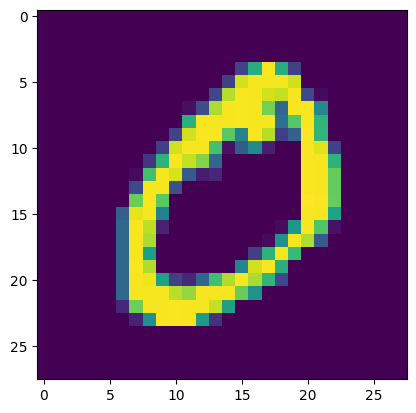

0


In [35]:
n = 1
img = x_train_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_train_org[n])

In [36]:
x_train = x_train_org.reshape(60000, 784)
x_test = x_test_org.reshape(10000, 784)

In [37]:
# Векторизованные операции
# Применяются к каждому элементу массива отдельно
x_train = x_train.astype('float32') # преобразовываем x_train в тип float (цифры с плавающей точкой)
x_train = x_train / 255 # делим на 255, чтобы диапазон был от 0 до 1

x_test = x_test.astype('float32')
x_test = x_test / 255

In [38]:
y_train = utils.to_categorical(y_train_org, 10)
y_test = utils.to_categorical(y_test_org, 10)

**Создаем последовательную модель**

In [39]:
model = Sequential()
# Входной полносвязный слой, 800 нейронов, 784 входа в каждый нейрон
model.add(Dense(800, input_dim=784, activation="relu"))
# ещё один скрытый слой
model.add(Dense(400, activation="relu"))
# Выходной полносвязный слой, 10 нейронов (по количеству рукописных цифр)
model.add(Dense(10, activation="softmax"))

###Компилируем сеть

In [40]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 400)            │       320,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 952,410 (3.63 MB)

 Trainable params: 952,410 (3.63 MB)

 Non-trainable params: 0 (0.00 B)

None


###Обучаем нейронную сеть

In [41]:
#fit - функция обучения нейронной сети
#x_train, y_train - обучающая выборка, входные и выходные данные
#batch_size - размер батча, количество примеров, которое обрабатывает нейронка перед одним изменением весов
#epochs - количество эпох, когда нейронка обучается на всех примерах выборки
#verbose - 0 - не визуализировать ход обучения, 1 - визуализировать
history = model.fit(x_train, y_train, batch_size=200, epochs=5, verbose=1, validation_data=(x_test, y_test))

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9326 - loss: 0.2291 - val_accuracy: 0.9587 - val_loss: 0.1317
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9757 - loss: 0.0799 - val_accuracy: 0.9772 - val_loss: 0.0753
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9851 - loss: 0.0493 - val_accuracy: 0.9765 - val_loss: 0.0722
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9886 - loss: 0.0344 - val_accuracy: 0.9787 - val_loss: 0.0728
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9924 - loss: 0.0235 - val_accuracy: 0.9816 - val_loss: 0.0639


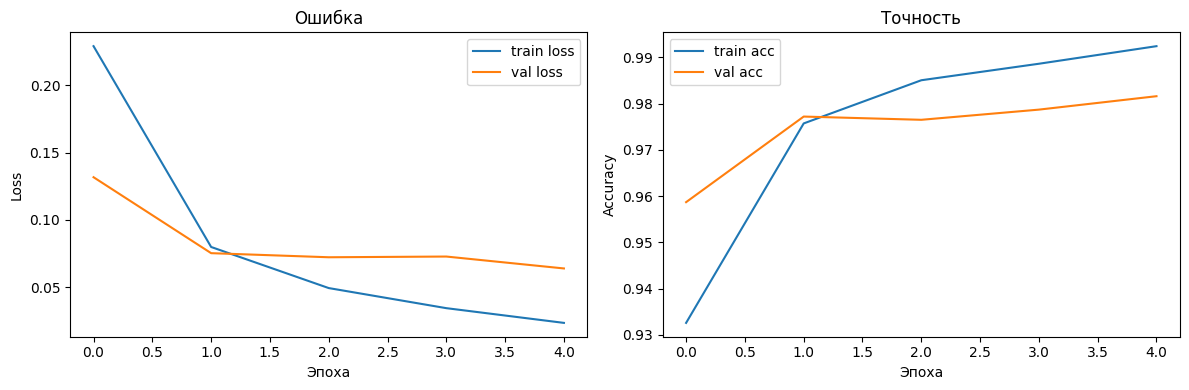

In [42]:
# График изменения ошибки и точности по эпохам
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Ошибка')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Точность')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

###Запускаем распознавание

In [43]:
# Оцениваем качество обучения сети на тестовых данных
scores = model.evaluate(x_test, y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 98.16%


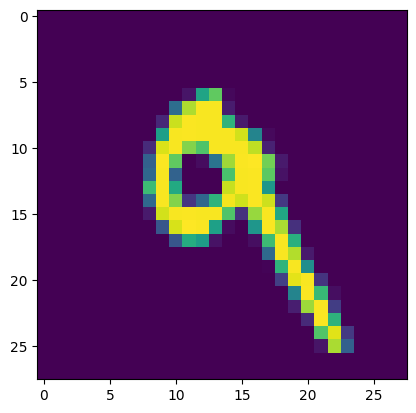

9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
[[2.4671974e-07 7.0631978e-07 2.0908941e-05 1.6008465e-03 3.6016674e-05
  1.5299227e-04 5.4573412e-10 9.5819581e-05 6.8882605e-06 9.9808562e-01]]


In [44]:
n=7
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test_org[n,:,:]
X = X.reshape(1, 784)
X = X.astype('float32')
X = X / 255
prediction = model.predict(X)
print(prediction)

In [45]:
prediction_N = np.argmax(prediction)
print(prediction_N)
print(np.sum(prediction))

9
1.0


In [46]:
model.save("mnist_dense.h5")

In [47]:
print("Сохраняем сеть")
# Сохраняем сеть для последующего использования
# Генерируем описание модели в формате json
model_json = model.to_json()
json_file = open("mnist_model.json", "w")
# Записываем архитектуру сети в файл
json_file.write(model_json)
json_file.close()
# Записываем данные о весах в файл
model.save_weights("mnist_model.weights.h5")
print("Сохранение сети завершено")

Сохраняем сеть
Сохранение сети завершено


In [48]:
#from keras.utils import np_utils
from tensorflow.keras.models import model_from_json

print("Загружаю сеть из файлов")
# Загружаем данные об архитектуре сети
json_file = open("mnist_model.json", "r")
loaded_model_json = json_file.read()
json_file.close()
# Создаем модель
loaded_model = model_from_json(loaded_model_json)
# Загружаем сохраненные веса в модель
loaded_model.load_weights("mnist_model.weights.h5")
print("Загрузка сети завершена")

Загружаю сеть из файлов
Загрузка сети завершена


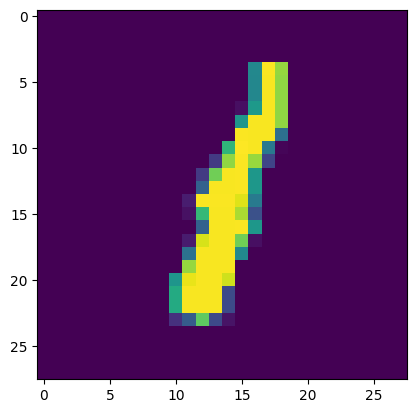

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[[1.30459043e-07 9.99889016e-01 9.44692431e-07 3.24235359e-08
  2.73231512e-06 1.18227241e-07 7.73464421e-07 9.24993074e-05
  1.37857405e-05 1.18519798e-08]]


In [49]:
n=89
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test_org[n,:,:]
X = X.reshape(1, 784)
X = X.astype('float32')
X = X / 255
prediction = loaded_model.predict(X)
print(prediction)

In [50]:
prediction = np.argmax(prediction)
print(prediction)

1


# Распознавание рукописных цифр сверточной нейронной сетью

In [51]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

In [52]:
# В Keras встроены средства работы с популярными наборами данных
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

In [53]:
x_train = x_train_org.astype('float32')
x_train = x_train / 255

x_test = x_test_org.astype('float32')
x_test = x_test / 255

In [54]:
x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)

In [55]:
y_train = utils.to_categorical(y_train_org, 10)
y_test = utils.to_categorical(y_test_org, 10)

In [56]:
model = Sequential()
#model.add(BatchNormalization(input_shape=(28, 28, 1)))

model.add(Conv2D(32, kernel_size=(4, 4), padding='same', input_shape=(28, 28, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(4, 4), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(BatchNormalization())
model.add(Conv2D(128, kernel_size=(4, 4), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [57]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 432,746 (1.65 MB)

 Trainable params: 432,554 (1.65 MB)

 Non-trainable params: 192 (768.00 B)

None


In [58]:
history_cnn = model.fit(x_train, y_train, batch_size=200, epochs=5, verbose=1, validation_data=(x_test, y_test))

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 145s 473ms/step - accuracy: 0.9158 - loss: 0.2689 - val_accuracy: 0.1135 - val_loss: 5.5885
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 138s 459ms/step - accuracy: 0.9783 - loss: 0.0725 - val_accuracy: 0.9846 - val_loss: 0.0511
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 144s 466ms/step - accuracy: 0.9836 - loss: 0.0527 - val_accuracy: 0.9904 - val_loss: 0.0274
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 139s 462ms/step - accuracy: 0.9870 - loss: 0.0424 - val_accuracy: 0.9917 - val_loss: 0.0218
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 143s 465ms/step - accuracy: 0.9888 - loss: 0.0375 - val_accuracy: 0.9932 - val_loss: 0.0185


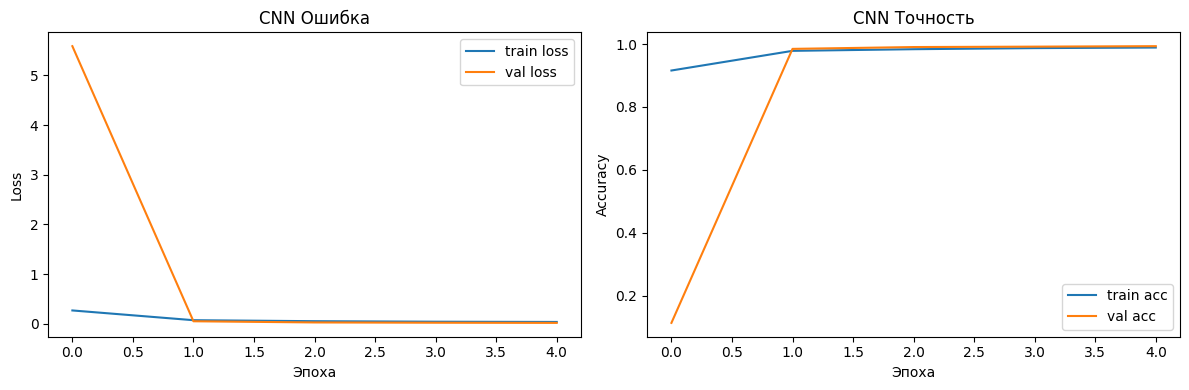

In [59]:
# График обучения сверточной сети
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='train loss')
plt.plot(history_cnn.history['val_loss'], label='val loss')
plt.title('CNN Ошибка')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='train acc')
plt.plot(history_cnn.history['val_accuracy'], label='val acc')
plt.title('CNN Точность')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [60]:
# Оцениваем качество обучения сети на тестовых данных
scores = model.evaluate(x_test, y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 99.32%


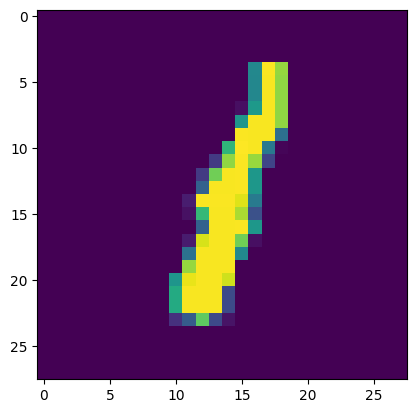

1
(28, 28, 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
[[5.8270619e-09 9.9999762e-01 3.0342772e-08 4.0324633e-09 2.0976962e-07
  3.1690706e-07 1.5628791e-06 2.2638382e-08 1.7967582e-07 2.8608481e-08]]


In [61]:
n=89
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test[n,:,:,:]
print(X.shape)
X = np.expand_dims(X, axis=0)
prediction = model.predict(X)
print(prediction)

In [62]:
prediction = np.argmax(prediction)
print(prediction)

1


In [63]:
print("Сохраняем сеть")
# Сохраняем сеть для последующего использования
# Генерируем описание модели в формате json
model_json = model.to_json()
json_file = open("mnist_model_CNN.json", "w")
# Записываем архитектуру сети в файл
json_file.write(model_json)
json_file.close()
# Записываем данные о весах в файл
model.save_weights("mnist_model_CNN.weights.h5")
print("Сохранение сети завершено")

Сохраняем сеть
Сохранение сети завершено


In [64]:
from tensorflow.keras.models import model_from_json

print("Загружаю сеть из файлов")
# Загружаем данные об архитектуре сети
json_file = open("mnist_model_CNN.json", "r")
loaded_model_json = json_file.read()
json_file.close()
# Создаем модель
loaded_model = model_from_json(loaded_model_json)
# Загружаем сохраненные веса в модель
loaded_model.load_weights("mnist_model_CNN.weights.h5")
print("Загрузка сети завершена")

Загружаю сеть из файлов
Загрузка сети завершена


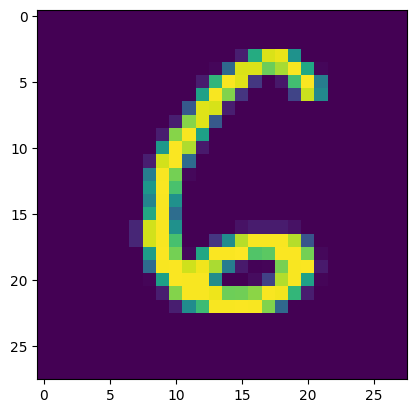

6
(28, 28, 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
[[1.0930734e-07 4.3741823e-11 3.8314303e-09 2.7875360e-11 6.6898631e-10
  9.0389420e-07 9.9999809e-01 1.6049729e-14 7.8517462e-07 2.5792604e-10]]


In [65]:
n=98
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test[n,:,:,:]
print(X.shape)
X = np.expand_dims(X, axis=0)
prediction = loaded_model.predict(X)
print(prediction)

In [66]:
prediction = np.argmax(prediction)
print(prediction)

6


# Тестирование собственного изображения

(97, 97)


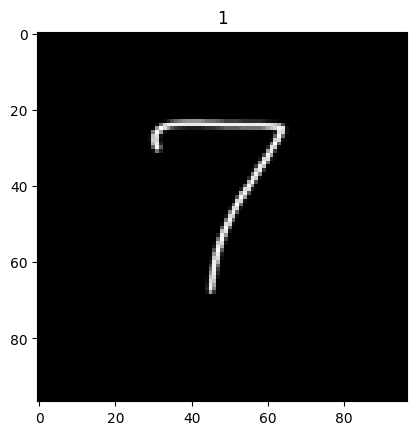

In [67]:
import cv2

# первое изображение
image1 = cv2.imread('/content/my_1.png', cv2.IMREAD_GRAYSCALE)
print(image1.shape)
plt.imshow(image1, cmap='gray')
plt.title('1')
plt.show()

In [68]:
dim = (28, 28)
resized1 = cv2.resize(image1, dim, interpolation=cv2.INTER_AREA)
print(resized1.shape)

(28, 28)


In [69]:
resized1 = np.expand_dims(resized1, axis=0)
resized1 = np.expand_dims(resized1, axis=3)
print(resized1.shape)

(1, 28, 28, 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Вероятности: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Распознанная цифра: 3


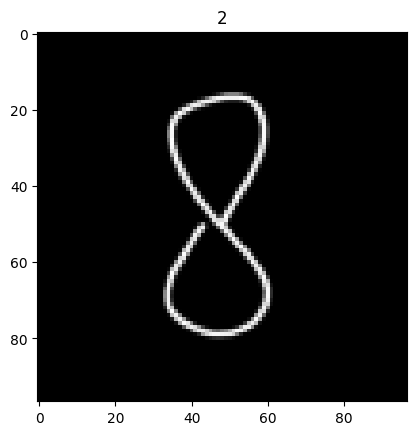

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Вероятности: [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]
Распознанная цифра: 8


In [70]:
prediction = loaded_model.predict(resized1)
print('Вероятности:', prediction)
prediction = np.argmax(prediction)
print('Распознанная цифра:', prediction)

#Второе
image2 = cv2.imread('/content/my_2.png', cv2.IMREAD_GRAYSCALE)
resized2 = cv2.resize(image2, (28, 28), interpolation=cv2.INTER_AREA)
resized2 = np.expand_dims(resized2, axis=0)
resized2 = np.expand_dims(resized2, axis=3)

plt.imshow(image2, cmap='gray')
plt.title('2')
plt.show()

prediction2 = loaded_model.predict(resized2)
print('Вероятности:', prediction2)
print('Распознанная цифра:', np.argmax(prediction2))